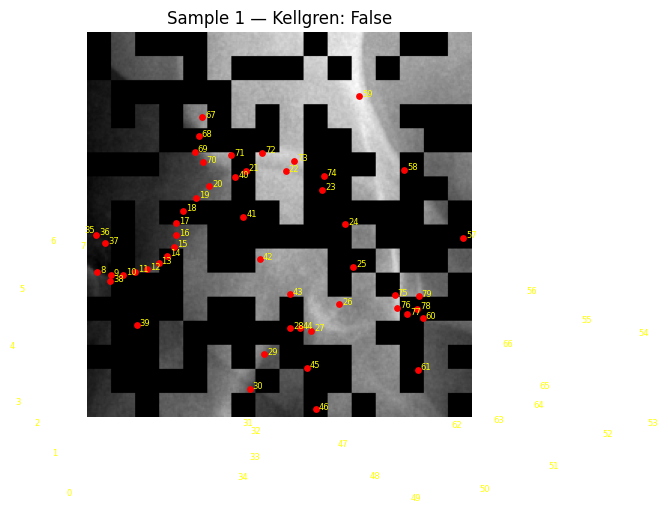

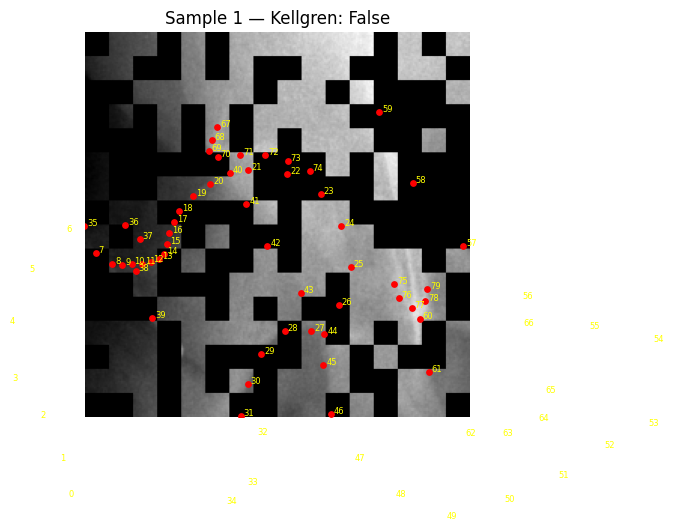

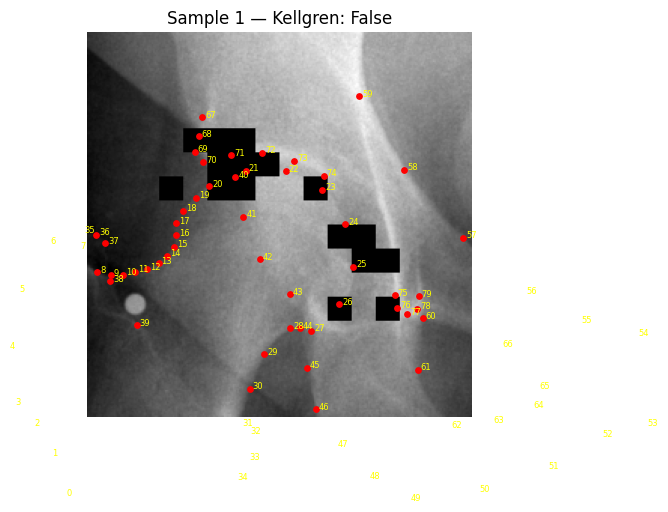

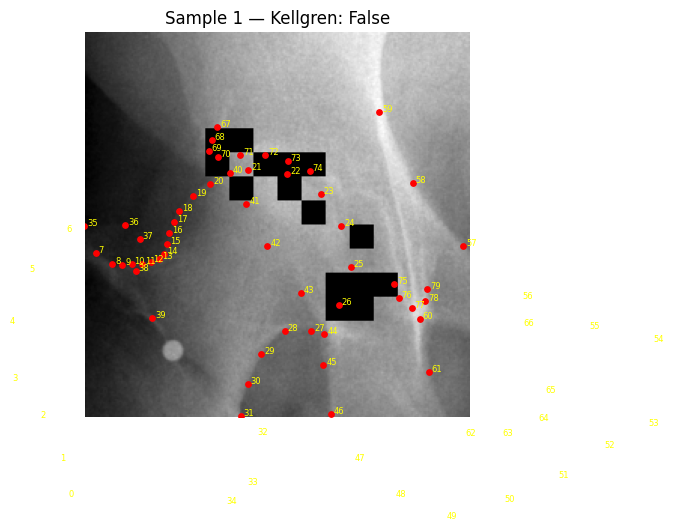

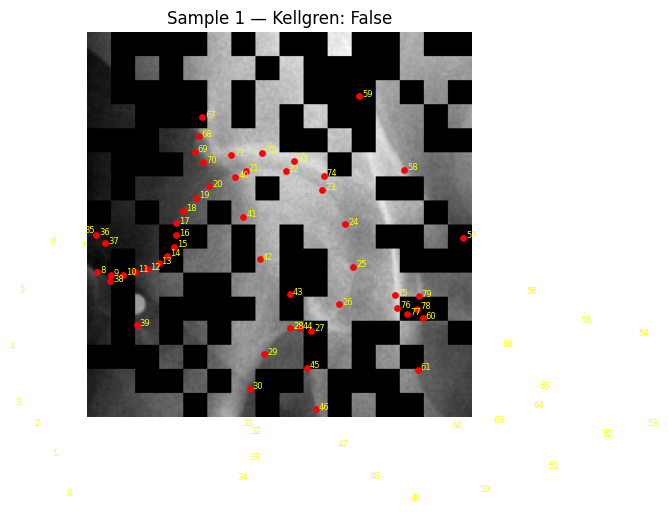

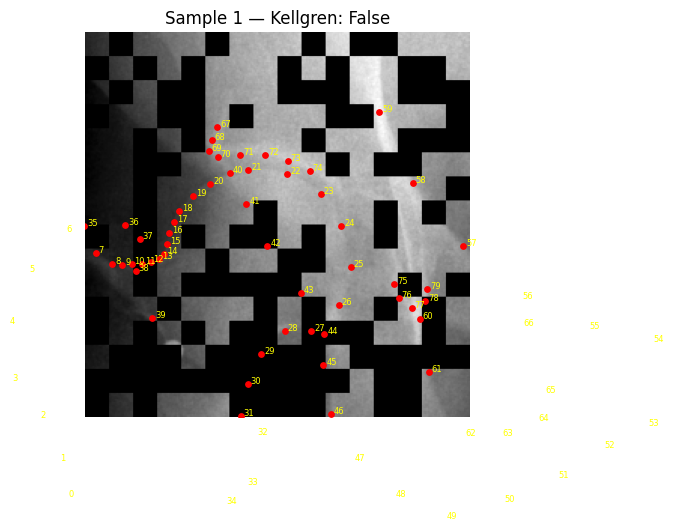

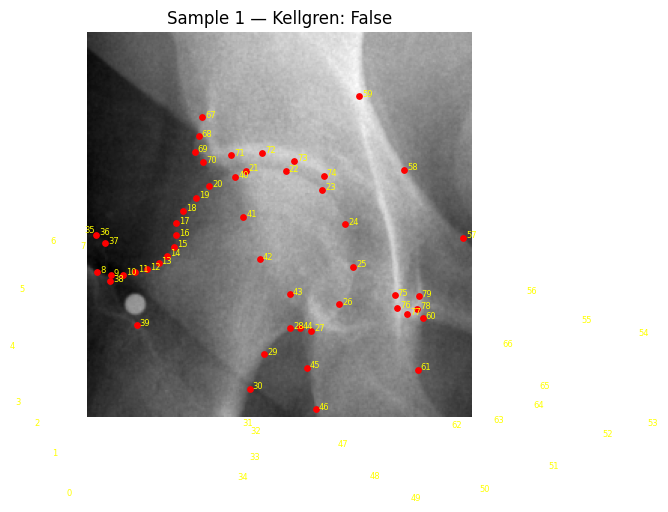

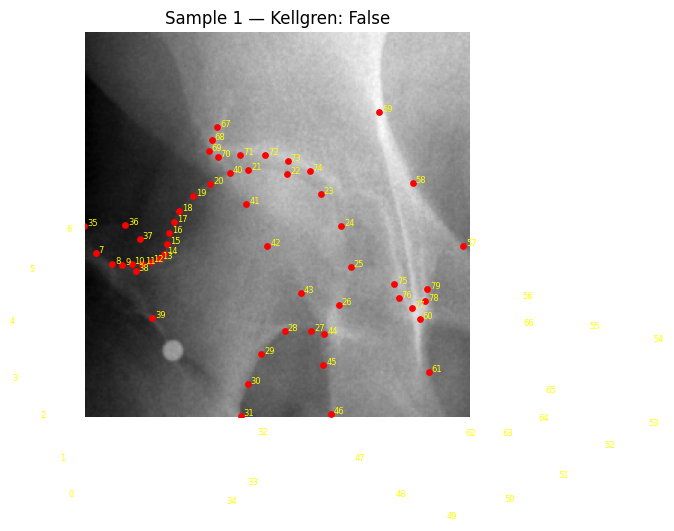

In [5]:
from matplotlib import transforms
import torch
from torchvision import transforms
from checkDataset import CheckDataset
from sample_dataset import sample_and_plot_from_loader

dataset_name = "check_test"

dataset = CheckDataset(
    processed_root="data/" + dataset_name,
    patients_path="data/" + dataset_name + "/patients",
    targets_json="data/"+ dataset_name + "/targets.json",
    split_txt="data/" + dataset_name + "/train_test_val_split.txt",
    desired_split="train",
    transform=transforms.Normalize(mean=[0.5], std=[0.5]), # normalize image intensity
    augment=False)

data_loader = torch.utils.data.DataLoader(
    dataset, 
    batch_size=8, 
    shuffle=False, #dont shuffle test sets 
    num_workers=2,
    pin_memory=True,
    persistent_workers=True)


print_masked = True
patch_size = 16
mask_rate = 0.5
num_samples = 1

_, height, width = data_loader.dataset[0]["image"].shape
num_patches = height // patch_size * width // patch_size
num_masked = int(num_patches * mask_rate)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': True,
    'mask_non_roi': True
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': True,
    'mask_non_roi': False
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': False,
    'mask_non_roi': True
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': False,
    'mask_non_roi': False
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)
    
